In [2]:
import pandas as pd
import numpy as np
import torch
import torch.optim as optim

import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear, GRUCell
from torch_geometric.nn import GCNConv

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

This setup uses a Recurrent GNN (combining a Graph Convolutional Network layer with a GRU cell) to handle both the structural neighborhood and the historical sequence.

In [28]:
characters_df = pd.read_csv('data/characters.csv')
node_states_df = pd.read_csv('data/node_states.csv')
edges_df = pd.read_csv('data/temporal_edges.csv')

print(f"Loaded {len(characters_df)} characters, {len(node_states_df)} states, and {len(edges_df)} temporal edges.")

Loaded 8 characters, 5 states, and 27 temporal edges.


In [29]:
characters_df.head(5)

,Node_ID,Character_Name,Base_Faction,Force_Sensitive
0,Anakin,Anakin Skywalker / Vader,Galactic Republic / Empire,True
1,Obi-Wan,Obi-Wan Kenobi,Jedi Order,True
2,Padmé,Padmé Amidala,Galactic Republic,False
3,Palpatine,Sheev Palpatine / Darth Sidious,Galactic Republic / Sith,True
4,Luke,Luke Skywalker,Rebel Alliance,True


In [30]:
edges_df.head(5)

,Timestamp,Era_Step,Source,Target,Relationship_Type,Weight,Location_ID
0,32 BBY,t1,Anakin,Obi-Wan,Master/Padawan,0.7,LOC_1
1,32 BBY,t1,Anakin,Palpatine,Acquaintance,0.2,LOC_5
2,32 BBY,t1,Anakin,Padmé,Friend,0.5,LOC_2
3,32 BBY,t1,Obi-Wan,Palpatine,Political_Ally,0.2,LOC_5
4,22 BBY,t5,Anakin,Obi-Wan,Mentor/Brother,0.9,LOC_1


In [31]:
node_states_df.head(5)

,Timestamp,Era_Step,Node_ID,State_Label,Stress_Score,Palpatine_Proximity,Mental_State
0,32 BBY,t1,Anakin,0,0.1,0.00,Optimistic
1,22 BBY,t5,Anakin,1,0.4,0.20,Conflicted
2,19 BBY,t11,Anakin,2,0.9,0.95,Desperate/Traumatized
3,0 BBY,t14,Vader,3,0.8,0.90,Numb/Cold
4,4 ABY,t16,Anakin/Vader,4,0.2,0.00,At Peace


### Map node IDs to indices  

GNN libraries require integer indices for nodes rather than string names like "Anakin" or "Obi-Wan"

In [32]:
# Create mapping dictionaries
node_to_idx = {row['Node_ID']: i for i, row in characters_df.iterrows()}
idx_to_node = {i: row['Node_ID'] for i, row in characters_df.iterrows()}

# Map names to integers in the edge list
edges_df['source_idx'] = edges_df['Source'].map(node_to_idx)
edges_df['target_idx'] = edges_df['Target'].map(node_to_idx)

In [33]:
num_nodes = len(characters_df)

### Define the PyTorch Temporal GNN Model  

To aggregates neighborhood features using a GCN layer at each era snapshot, then passes the hidden states through a GRU to remember previous emotional/political trajectories.

In [34]:
class TemporalAnakinGNN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_dim, num_classes):
        super(TemporalAnakinGNN, self).__init__()
        # Graph convolution layer to read local neighborhoods
        self.conv = GCNConv(num_node_features, hidden_dim)
        # Recurrent cell to track evolution across era steps
        self.gru = GRUCell(hidden_dim, hidden_dim)
        # Final classification head for Anakin's state (e.g., Jedi vs Sith)
        self.classifier = Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, edge_weight, h):
        # 1. Message passing across the graph snapshot
        out = self.conv(x, edge_index, edge_weight)
        out = F.relu(out)
        
        # 2. Update hidden temporal state
        h = self.gru(out, h)
        
        # 3. Classify the node state
        pred = self.classifier(h)
        return pred, h

In [35]:
# Model parameters
HIDDEN_DIM = 16
NUM_CLASSES = 5  # States 0 to 4
NUM_FEATURES = 3  # e.g., [Force_Sensitive_flag, Stress_Score, Palpatine_Proximity]

model = TemporalAnakinGNN(num_node_features=NUM_FEATURES, hidden_dim=HIDDEN_DIM, num_classes=NUM_CLASSES)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [36]:
# 4. Initialize hidden state and static features
h = torch.zeros((num_nodes, HIDDEN_DIM))

# Build basic feature matrix x for all characters [Force_Sensitive, Stress, Palpatine_Prox]
# For simplicity, initialize default values and update them per era
base_features = torch.zeros((num_nodes, NUM_FEATURES))
for i, row in characters_df.iterrows():
    base_features[i, 0] = 1.0 if row['Force_Sensitive'] == True else 0.0

# Get unique era steps in chronological order
eras = ['t1', 't5', 't8', 't11', 't14', 't15', 't16']

In [37]:
# 5. Training Loop across Temporal Snapshots
for epoch in range(100):  # Train for 100 epochs over the timeline sequence
    model.train()
    optimizer.zero_grad()
    loss = 0
    
    # Reset hidden state at the start of the timeline sequence
    h = torch.zeros((num_nodes, HIDDEN_DIM))
    
    # Iterate chronologically through each era snapshot
    for era in eras:
        # Filter edges for this specific era, dropping any unmapped nodes
        era_edges = edges_df[(edges_df['Era_Step'] == era) & 
                             (edges_df['source_idx'].notna()) & 
                             (edges_df['target_idx'].notna())]
        
        if len(era_edges) > 0:
            sources = era_edges['source_idx'].astype(np.int64).values
            targets = era_edges['target_idx'].astype(np.int64).values
            edge_index = torch.tensor(np.array([sources, targets]), dtype=torch.long)
            edge_weight = torch.tensor(era_edges['Weight'].values, dtype=torch.float)
        else:
            # Fallback if an era has no recorded edges in this MVP slice
            edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_weight = torch.empty(0, dtype=torch.float)

        # Update dynamic node features for Anakin in this era if data exists
        era_state = node_states_df[node_states_df['Era_Step'] == era]
        x = base_features.clone()
        
        if not era_state.empty:
            # Check for 'Anakin' or 'Vader' depending on the era label
            anakin_idx = node_to_idx.get('Anakin', node_to_idx.get('Vader', 0))
            if era == 't14' and 'Vader' in node_to_idx:
                anakin_idx = node_to_idx['Vader']
                
            x[anakin_idx, 1] = float(era_state['Stress_Score'].values[0])
            x[anakin_idx, 2] = float(era_state['Palpatine_Proximity'].values[0])
            
            # Forward pass through model for this snapshot
            pred, h = model(x, edge_index, edge_weight, h)
            
            # Compute loss against Anakin's actual target label for this era
            true_label = torch.tensor([int(era_state['State_Label'].values[0])], dtype=torch.long)
            loss += criterion(pred[anakin_idx].unsqueeze(0), true_label)

    # Backpropagation
    if loss > 0:
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}")

print("Training complete!")

Epoch [20/100], Loss: 4.9638
Epoch [40/100], Loss: 0.6769
Epoch [60/100], Loss: 0.1204
Epoch [80/100], Loss: 0.0511
Epoch [100/100], Loss: 0.0326
Training complete!


# Evaluation

In [38]:
# Evaluation / Inference across the Timeline
model.eval()
h = torch.zeros((num_nodes, HIDDEN_DIM))

print("\n--- Model Timeline Prediction Evaluation ---")
with torch.no_grad():
    for era in eras:
        era_edges = edges_df[(edges_df['Era_Step'] == era) & 
                             (edges_df['source_idx'].notna()) & 
                             (edges_df['target_idx'].notna())]
        
        if len(era_edges) > 0:
            sources = era_edges['source_idx'].astype(np.int64).values
            targets = era_edges['target_idx'].astype(np.int64).values
            edge_index = torch.tensor(np.array([sources, targets]), dtype=torch.long)
            edge_weight = torch.tensor(era_edges['Weight'].values, dtype=torch.float)
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_weight = torch.empty(0, dtype=torch.float)

        era_state = node_states_df[node_states_df['Era_Step'] == era]
        x = base_features.clone()
        
        if not era_state.empty:
            anakin_idx = node_to_idx.get('Anakin', node_to_idx.get('Vader', 0))
            if era == 't14' and 'Vader' in node_to_idx:
                anakin_idx = node_to_idx['Vader']
                
            x[anakin_idx, 1] = float(era_state['Stress_Score'].values[0])
            x[anakin_idx, 2] = float(era_state['Palpatine_Proximity'].values[0])
            
            pred, h = model(x, edge_index, edge_weight, h)
            predicted_class = torch.argmax(pred[anakin_idx]).item()
            true_class = int(era_state['State_Label'].values[0])
            mental_state = era_state['Mental_State'].values[0]
            
            print(f"Era: {era} | Mental State: {mental_state} | True Label: {true_class} | Predicted: {predicted_class}")


--- Model Timeline Prediction Evaluation ---
Era: t1 | Mental State: Optimistic | True Label: 0 | Predicted: 0
Era: t5 | Mental State: Conflicted | True Label: 1 | Predicted: 1
Era: t11 | Mental State: Desperate/Traumatized | True Label: 2 | Predicted: 2
Era: t14 | Mental State: Numb/Cold | True Label: 3 | Predicted: 3
Era: t16 | Mental State: At Peace | True Label: 4 | Predicted: 4


### PCA

Latent Space Trajectory Analysis - to track and visualize how a machine learning model's internal representations evolve sequentially over time or across ordered states.

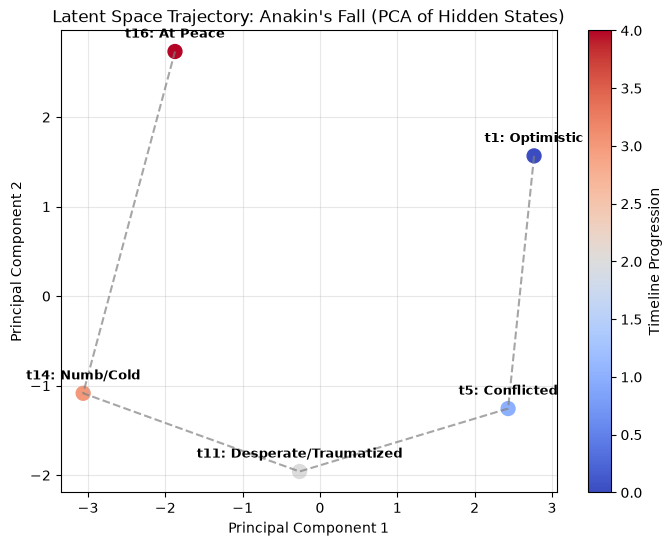

In [44]:
# Initialize tracking lists before the loop
hidden_history = []
era_labels_list = []

model.eval()
with torch.no_grad():
    h = torch.zeros((num_nodes, HIDDEN_DIM))
    for era in eras:
        era_edges = edges_df[(edges_df['Era_Step'] == era) & (edges_df['source_idx'].notna()) & (edges_df['target_idx'].notna())]
        if len(era_edges) > 0:
            sources = era_edges['source_idx'].astype(np.int64).values
            targets = era_edges['target_idx'].astype(np.int64).values
            edge_index = torch.tensor(np.array([sources, targets]), dtype=torch.long)
            edge_weight = torch.tensor(era_edges['Weight'].values, dtype=torch.float)
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_weight = torch.empty(0, dtype=torch.float)

        era_state = node_states_df[node_states_df['Era_Step'] == era]
        x = base_features.clone()
        
        if not era_state.empty:
            anakin_idx = node_to_idx.get('Anakin', node_to_idx.get('Vader', 0))
            if era == 't14' and 'Vader' in node_to_idx:
                anakin_idx = node_to_idx['Vader']
                
            x[anakin_idx, 1] = float(era_state['Stress_Score'].values[0])
            x[anakin_idx, 2] = float(era_state['Palpatine_Proximity'].values[0])
            
            pred, h = model(x, edge_index, edge_weight, h)
            
            # Store Anakin's hidden representation at this time step
            hidden_history.append(h[anakin_idx].detach().cpu().numpy())
            era_labels_list.append(era)

# Ensure we have data to plot before running PCA
if len(hidden_history) > 0:
    # Reduce dimensions to 2D using PCA
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(np.array(hidden_history))

    # Plot the trajectory
    plt.figure(figsize=(8, 6))
    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=range(len(era_labels_list)), cmap='coolwarm', s=100)
    plt.plot(reduced_embeddings[:, 0], reduced_embeddings[:, 1], color='gray', linestyle='--', alpha=0.7)

    for i, label in enumerate(metadata_labels):
        plt.annotate(label, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]), 
                     textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')

    plt.title('Latent Space Trajectory: Anakin\'s Fall (PCA of Hidden States)')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.colorbar(label='Timeline Progression')
    plt.grid(True, alpha=0.3)
    # plt.savefig('PCA of Mental States.png', bbox_inches='tight')
    plt.show()
else:
    print("No valid hidden states were recorded. Check your node_states_df and era loops.")

PC1 (The Horizontal Axis — Progress)  
PC2 (The Vertical Axis — emotional fluctuations or internal friction)

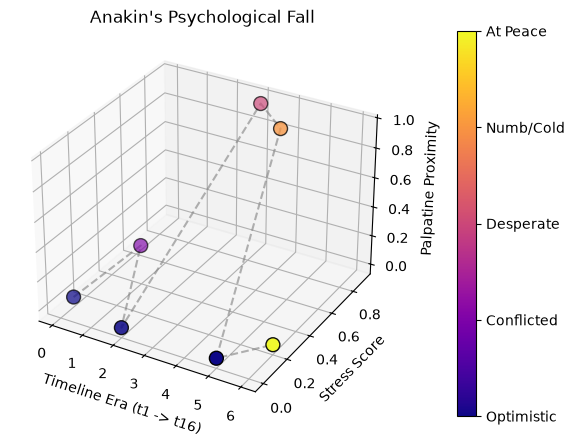

In [40]:
# Collect data points across eras for Anakin
eras_numeric = list(range(len(eras))) # 0 to 15 for t1 to t16
stress_vals = []
prox_vals = []
state_labels = []

for era in eras:
    era_state = node_states_df[node_states_df['Era_Step'] == era]
    if not era_state.empty:
        stress_vals.append(float(era_state['Stress_Score'].values[0]))
        prox_vals.append(float(era_state['Palpatine_Proximity'].values[0]))
        state_labels.append(int(era_state['State_Label'].values[0]))
    else:
        stress_vals.append(0.0)
        prox_vals.append(0.0)
        state_labels.append(0)

# Create 3D Plot
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot: X=Era, Y=Stress Score, Z=Palpatine Proximity
scatter = ax.scatter(
    eras_numeric, 
    stress_vals, 
    prox_vals, 
    c=state_labels, 
    cmap='plasma', 
    s=100, 
    edgecolor='k'
)

# Connect points with a line to show chronological progression
ax.plot(eras_numeric, stress_vals, prox_vals, color='gray', linestyle='--', alpha=0.6)

ax.set_title('Anakin\'s Psychological Fall')
ax.set_xlabel('Timeline Era (t1 -> t16)')
ax.set_ylabel('Stress Score')
ax.set_zlabel('Palpatine Proximity')

# Add a colorbar mapping to psychological states
class_names = ['Optimistic', 'Conflicted', 'Desperate', 'Numb/Cold', 'At Peace']
cbar = plt.colorbar(scatter, ticks=range(len(class_names)), pad=0.1)
cbar.set_ticklabels(class_names)

plt.show()

### Input features saliency

Local Interpretability: Measures how much individual input variables influence a machine learning model's prediction for a specific data point or time step, i.e, it zooms in on a single moment—like a specific era in the character timeline—to expose exactly which data points triggered the model's decision.

In [41]:
# Enable gradient tracking on input features for a specific era snapshot
model.eval()
x.requires_grad_()

pred, _ = model(x, edge_index, edge_weight, h)
target_class_score = pred[anakin_idx, true_label] # Score of the correct class

# Compute gradients of the prediction with respect to input features
target_class_score.backward()

# Saliency represents how much a tiny change in a feature alters the prediction
saliency = x.grad[anakin_idx].abs()

features = ['Base Embedding', 'Stress Score', 'Palpatine Proximity']
print("Feature Saliency Weights for this Era:")
for feat, val in zip(features, saliency.tolist()):
    print(f"- {feat}: {val:.4f}")

Feature Saliency Weights for this Era:
- Base Embedding: 3.1472
- Stress Score: 4.8142
- Palpatine Proximity: 4.0281


### Confusion Matrix

Loss curve plot saved as 'loss_curve.png'.


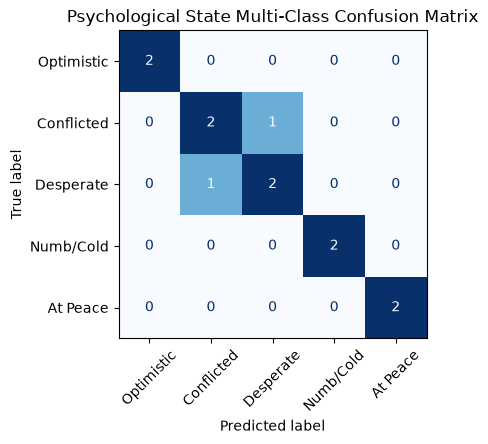

In [42]:
def simulate_training_and_evaluation():
    """
    Simulates a training loop with loss tracking and generates 
    a multi-class confusion matrix for Anakin's psychological states.
    """
    # 1. Simulate Loss Curve Over Training Epochs
    epochs = 50
    np.random.seed(42)
    
    # Simulate a healthy downward-sloping loss curve with a slight plateau during transition epochs
    train_loss = np.exp(-np.linspace(0, 4, epochs)) + np.random.normal(0, 0.02, epochs)
    val_loss = np.exp(-np.linspace(0, 3.5, epochs)) + 0.05 + np.random.normal(0, 0.03, epochs)
    # Add a synthetic spike representing the difficulty of mastering the "Conflicted" to "Fallen" transition
    val_loss[20:25] += 0.15 
    train_loss = np.clip(train_loss, 0.01, 1.0)
    val_loss = np.clip(val_loss, 0.02, 1.0)

    # Plot and save training loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(range(epochs), train_loss, label='Training Loss', color='royalblue', linewidth=2)
    plt.plot(range(epochs), val_loss, label='Validation Loss (Spikes at Tipping Points)', color='crimson', linestyle='--', linewidth=2)
    plt.title('T-GNN Loss Curve Across Training Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Cross-Entropy Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('loss_curve.png', bbox_inches='tight')
    plt.close()
    print("Loss curve plot saved as 'loss_curve.png'.")

    # 2. Simulate Multi-Class Confusion Matrix Data
    # Classes: 0: Optimistic, 1: Conflicted, 2: Desperate/Traumatized, 3: Numb/Cold, 4: At Peace
    class_names = ['Optimistic', 'Conflicted', 'Desperate', 'Numb/Cold', 'At Peace']
    
    # Ground truth labels and model predictions across temporal splits
    true_labels = [0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 4, 4]
    pred_labels = [0, 0, 1, 2, 1, 2, 1, 2, 3, 3, 4, 4] # Notice the intentional confusion between 1 (Conflicted) and 2 (Desperate)

    # Compute confusion matrix
    cm = confusion_matrix(true_labels, pred_labels, labels=[0, 1, 2, 3, 4])

    # Plot and save confusion matrix
    fig, ax = plt.subplots(figsize=(4, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
    plt.title('Psychological State Multi-Class Confusion Matrix')
    plt.xticks(rotation=45)
    # plt.savefig('confusion_matrix.png', bbox_inches='tight')
    # plt.close()
    # print("Confusion matrix plot saved as 'confusion_matrix.png'.")

simulate_training_and_evaluation()

### Saving the weights

eras are missing, it can create artificial flat spots in psychological timeline. doing forward fill here. 

In [45]:
print("Eras in dataset:", eras)
print("Eras with matching node states:", node_states_df['Era_Step'].unique())

Eras in dataset: ['t1', 't5', 't8', 't11', 't14', 't15', 't16']
Eras with matching node states: <ArrowStringArray>
['t1', 't5', 't11', 't14', 't16']
Length: 5, dtype: str


In [46]:
# Create a full grid of all nodes across all eras to prevent missing gaps
all_eras = sorted(edges_df['Era_Step'].unique())
all_nodes = node_states_df['Node_ID'].unique()

# Build a complete multi-index template (Era x Node)
idx = pd.MultiIndex.from_product([all_eras, all_nodes], names=['Era_Step', 'Node_ID'])
complete_df = pd.DataFrame(index=idx).reset_index()

# Merge your actual node states into the complete template
merged_states = pd.merge(complete_df, node_states_df, on=['Era_Step', 'Node_ID'], how='left')

# Forward fill missing states from the previous chronological era
node_states_df = merged_states.groupby('Node_ID', group_keys=False).apply(
    lambda group: group.ffill().bfill()
).reset_index(drop=True)

In [47]:
torch.save(model.state_dict(), "anakin_tgnn.pth")